In [ ]:
# NOTE use FastLloyd/env.yml
import sys, os
from pathlib import Path

def _find_project_root():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / ".git").exists():
            return parent
    raise RuntimeError("Could not find project root (.git not found)")

root = str(_find_project_root())
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)

In [ ]:
#Load data

from src.helpers import *
import numpy as np
import pickle
datasets, k_dict, r_dict, l_inf_dict = get_grid_datasets_final()

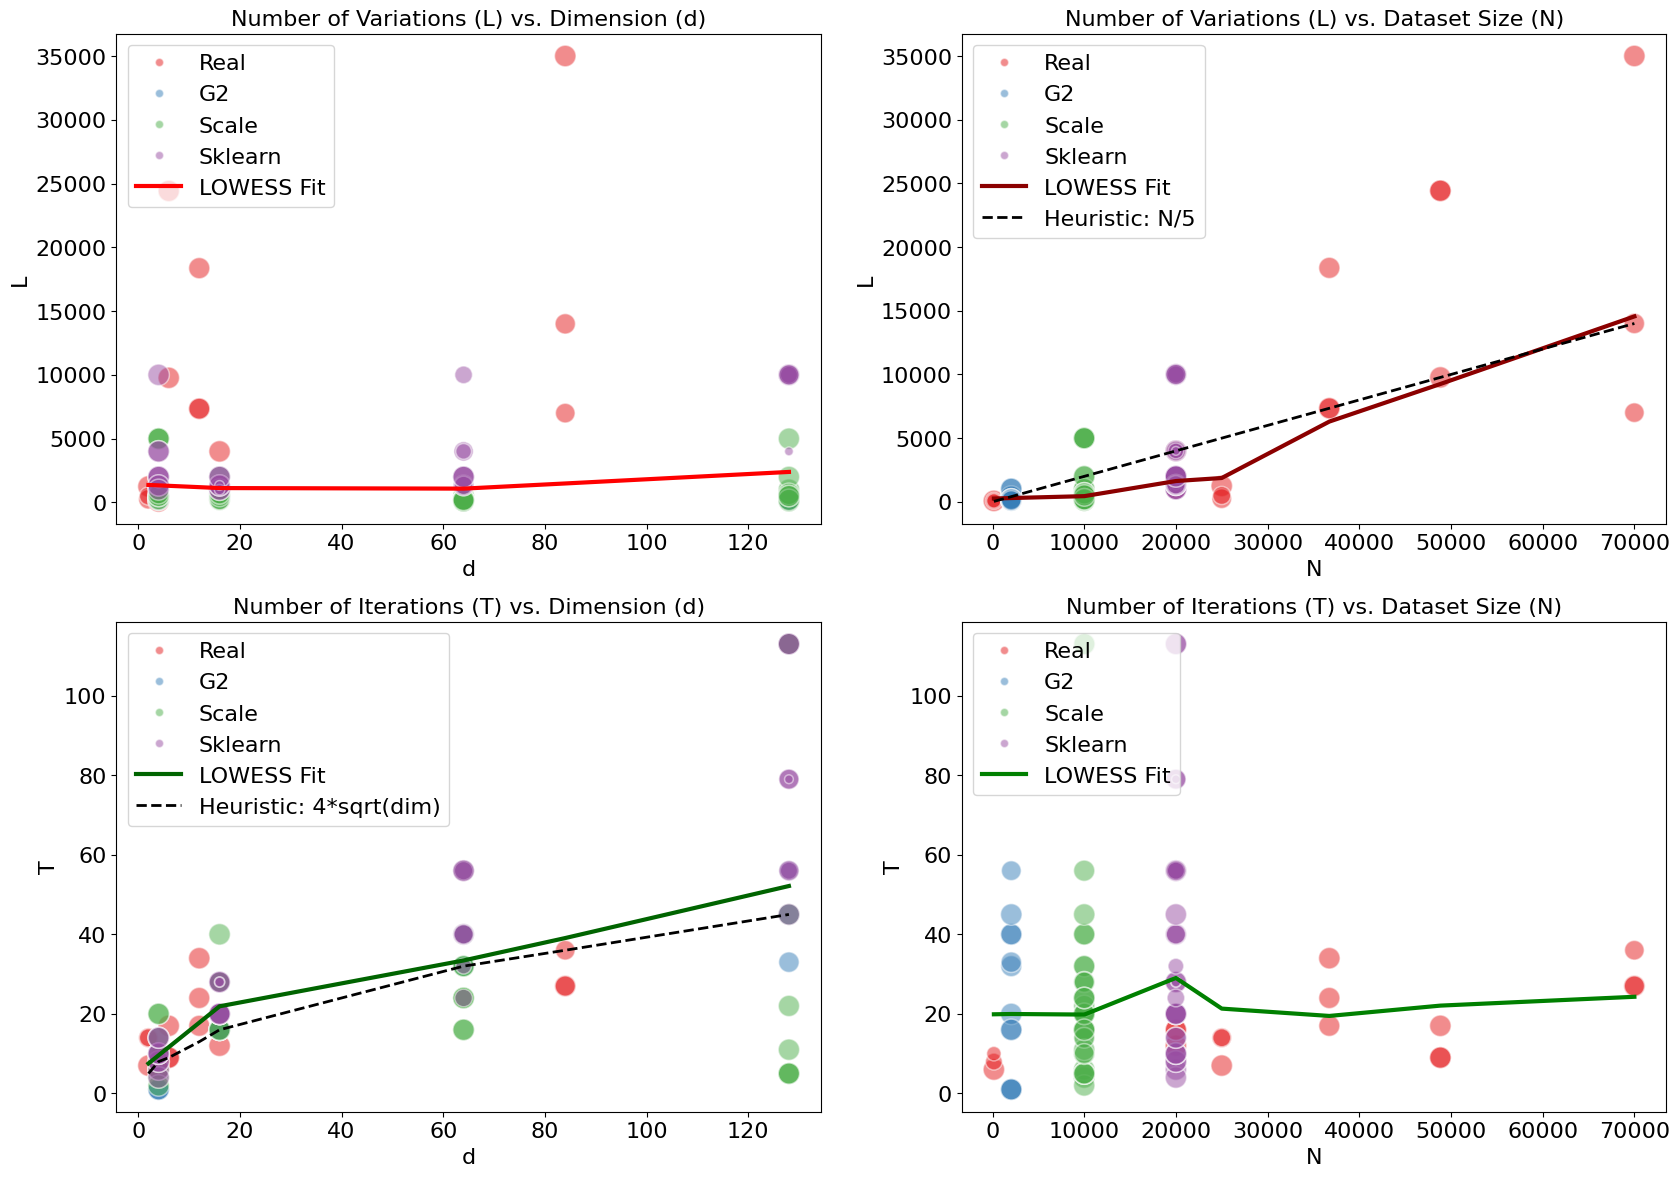

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import matplotlib.lines as mlines
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# --- 1. Data Extraction with Dataset Categorization ---
analysis_data = []
TOP_K = 3 
FOLDER ='result_final/grid_L_gen_eps1_May12'
for dataset_name, obj in datasets.items():
    dim = obj.shape[1] 
    n_samples = obj.shape[0]
    
    # Identify Dataset Type
    if dataset_name.startswith('sklearn'):
        ds_type = 'Sklearn'
    elif dataset_name.startswith('g2'):
        ds_type = 'G2'
    elif dataset_name.startswith('scale'):
        ds_type = 'Scale'
    else:
        ds_type = 'Real'

    l_vals_mapped = {tag: int(max(n_samples/tag, 4)) for tag in [2, 5, 10, 15, 20, 50, 100]}
    gen_vals_mapped = {tag: max(int(tag * np.sqrt(dim)), 1) for tag in [0.5, 1, 2, 3, 4, 5, 7, 10]}
    
    with open(f'{FOLDER}/grid_results_{dataset_name}.pkl', 'rb') as f:
        list_tuples = pickle.load(f)

    local_configs = defaultdict(list)
    for config, _, _, convergence in list_tuples:
        config_id = (config['L_tag'], config['gen_tag'])
        local_configs[config_id].append(convergence[-1])

    avg_losses = {cid: np.mean(losses) for cid, losses in local_configs.items()}
    sorted_configs = sorted(avg_losses.items(), key=lambda x: x[1])
    best_loss = sorted_configs[0][1]

    for rank, (config_id, current_loss) in enumerate(sorted_configs[:TOP_K]):
        proximity_score = best_loss / current_loss if current_loss != 0 else 1.0
        
        analysis_data.append({
            'dataset': dataset_name,
            'dataset_type': ds_type,
            'd': dim,
            'N': n_samples,
            'score': proximity_score,
            'L': l_vals_mapped[config_id[0]],
            'T': gen_vals_mapped[config_id[1]]
        })

df_analysis = pd.DataFrame(analysis_data)

# --- 2. Enhanced Plotting Function ---
def weighted_plot(ax, x_col, y_col, title, color, theory_line=None, theory_label=""):
    # 1. Scatterplot colored by Dataset Type
    # Size still represents 'score' (closeness to best)
    scatter = sns.scatterplot(
        data=df_analysis, x=x_col, y=y_col, 
        hue='dataset_type', size='score', alpha=0.5, 
        sizes=(40, 240), palette='Set1', ax=ax
    )
    
    # 2. Empirical Trend (LOWESS)
    # We plot this without a label here because regplot's legend behavior is tricky
    sns.regplot(
        data=df_analysis, x=x_col, y=y_col, 
        scatter=False, lowess=True, ax=ax, 
        line_kws={'color': color, 'linewidth': 3}
    )
    
    # 3. Theory Line
    if theory_line is not None:
        df_sorted = df_analysis.sort_values(x_col)
        ax.plot(df_sorted[x_col], theory_line(df_sorted), 
                color='black', linestyle='--', linewidth=2)
    
    # 4. Custom Legend Construction
    # This ensures we get Dataset Types + LOWESS + Theory in one clean box
    handles, labels = ax.get_legend_handles_labels()
    
    # Create custom proxy artists for the lines
    lowess_line = mlines.Line2D([], [], color=color, linewidth=3, label='LOWESS Fit')
    theory_proxy = mlines.Line2D([], [], color='black', linestyle='--', linewidth=2, label=theory_label)
    
    # Combine handles: Dataset Types (first few) + our new lines
    # We filter out the 'score' handles to keep it clean
    type_handles = [h for h, l in zip(handles, labels) if l in df_analysis['dataset_type'].unique()]
    type_labels = [l for l in labels if l in df_analysis['dataset_type'].unique()]
    
    new_handles = type_handles + [lowess_line]
    if theory_line is not None:
        new_handles.append(theory_proxy)
        
    ax.legend(handles=new_handles, loc='upper left')
    ax.set_title(title)

# --- 3. Execute Grid ---
#set global font size for all text to 14
plt.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 16,      # axes title
    'axes.labelsize': 16,      # x/y axis labels
    'xtick.labelsize': 16,     # x tick labels
    'ytick.labelsize': 16,     # y tick labels
    'legend.fontsize': 16,     # legend text
    'figure.titlesize': 16,    # figure suptitle
})
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Define Theory Functions
l_theory_func = lambda df: df['N'].apply(lambda n: int(max(n / 5, 4)))
gen_theory_func = lambda df: df['d'].apply(lambda d: max(int(4 * np.sqrt(d)), 1))

weighted_plot(axes[0, 0], 'd', 'L', 'Number of Variations (L) vs. Dimension (d)', 'red')
weighted_plot(axes[0, 1], 'N', 'L', 'Number of Variations (L) vs. Dataset Size (N)', 'darkred', l_theory_func, 'Heuristic: N/5')
weighted_plot(axes[1, 0], 'd', 'T', 'Number of Iterations (T) vs. Dimension (d)', 'darkgreen', gen_theory_func, 'Heuristic: 4*sqrt(dim)')
weighted_plot(axes[1, 1], 'N', 'T', 'Number of Iterations (T) vs. Dataset Size (N)', 'green')

plt.savefig(
    'plots/Tuning_L_gen.pdf', 
    format='pdf', 
    bbox_inches='tight', 
    transparent=False
)
plt.show()
# Close the plot to free up memory
plt.close()

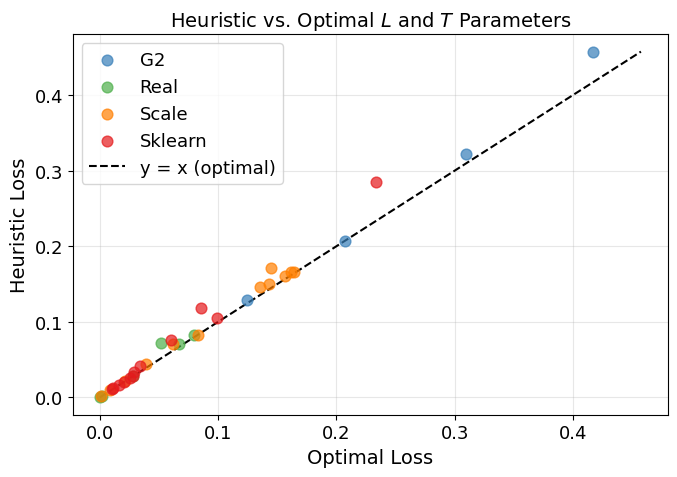

In [4]:

# --- Optimality gap: heuristic (L_tag=5, gen_tag=4) vs best config per dataset ---
FOLDER = 'result_final/grid_L_gen_eps1_May12'
HEURISTIC_L_TAG = 5    # L = N/5
HEURISTIC_GEN_TAG = 4  # T = 4*sqrt(d)

gap_data = []
for dataset_name, obj in datasets.items():
    dim = obj.shape[1]
    n_samples = obj.shape[0]

    if dataset_name.startswith('sklearn'):
        ds_type = 'Sklearn'
    elif dataset_name.startswith('g2'):
        ds_type = 'G2'
    elif dataset_name.startswith('scale'):
        ds_type = 'Scale'
    else:
        ds_type = 'Real'

    with open(f'{FOLDER}/grid_results_{dataset_name}.pkl', 'rb') as f:
        list_tuples = pickle.load(f)

    local_configs = defaultdict(list)
    for config, _, _, convergence in list_tuples:
        config_id = (config['L_tag'], config['gen_tag'])
        local_configs[config_id].append(convergence[-1] / n_samples)  # normalize by N

    avg_losses = {cid: np.mean(losses) for cid, losses in local_configs.items()}
    best_loss = min(avg_losses.values())
    heuristic_key = (HEURISTIC_L_TAG, HEURISTIC_GEN_TAG)

    if heuristic_key not in avg_losses:
        continue  # skip if heuristic config wasn't run

    heuristic_loss = avg_losses[heuristic_key]
    gap = (heuristic_loss - best_loss) / best_loss

    gap_data.append({
        'dataset': dataset_name,
        'dataset_type': ds_type,
        'best_loss': best_loss,
        'heuristic_loss': heuristic_loss,
        'gap': gap,
    })

df_gap = pd.DataFrame(gap_data).sort_values('gap')

# --- Plot ---
plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 14, 'axes.labelsize': 14,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'figure.titlesize': 14,
})

palette = {'Sklearn': '#e41a1c', 'G2': '#377eb8', 'Scale': '#ff7f00', 'Real': '#4daf4a'}
fig, ax = plt.subplots(figsize=(7, 5))

for ds_type, grp in df_gap.groupby('dataset_type'):
    ax.scatter(grp['best_loss'], grp['heuristic_loss'], label=ds_type,
               color=palette[ds_type], alpha=0.7, s=60, zorder=3)

lo = df_gap[['best_loss', 'heuristic_loss']].min().min()
hi = df_gap[['best_loss', 'heuristic_loss']].max().max()
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='y = x (optimal)')

ax.set_xlabel('Optimal Loss')
ax.set_ylabel('Heuristic Loss')
ax.set_title(r'Heuristic vs. Optimal $L$ and $T$ Parameters')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/heuristic_gap.pdf', format='pdf', bbox_inches='tight', transparent=False)
plt.show()
plt.close()




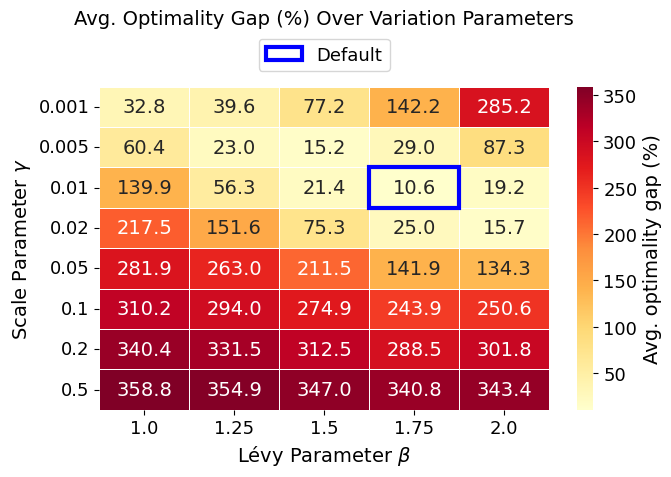

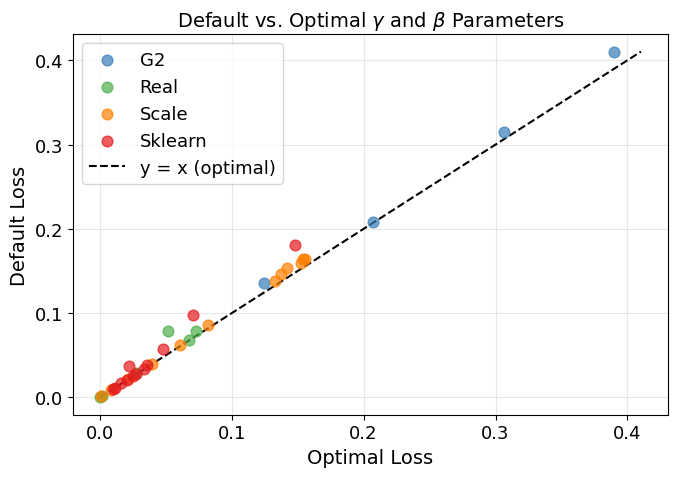

Datasets included: 34
Median optimality gap: 4.79%
Max optimality gap:    68.83%


In [5]:

# --- Mutation grid: gauss_var x levy_beta ---
MUT_FOLDER = 'result_final/mutation_grid_May12'
DEFAULT_GAUSS = 0.01
DEFAULT_LEVY  = 1.75

import os
import matplotlib.patches as mpatches

mut_data = []
for fname in sorted(os.listdir(MUT_FOLDER)):
    if not fname.endswith('.pkl'):
        continue
    dataset_name = fname.replace('grid_results_', '').replace('.pkl', '')

    if dataset_name.startswith('sklearn'):
        ds_type = 'Sklearn'
    elif dataset_name.startswith('g2'):
        ds_type = 'G2'
    elif dataset_name.startswith('scale'):
        ds_type = 'Scale'
    else:
        ds_type = 'Real'

    with open(f'{MUT_FOLDER}/{fname}', 'rb') as f:
        list_tuples = pickle.load(f)

    if dataset_name in datasets:
        n_samples = datasets[dataset_name].shape[0]
    else:
        n_samples = list_tuples[0][0]['L'] * list_tuples[0][0]['k']

    local_configs = defaultdict(list)
    for config, _, _, convergence in list_tuples:
        key = (config['gauss_var'], config['levy_beta'])
        local_configs[key].append(convergence[-1] / n_samples)

    for (gv, lb), losses in local_configs.items():
        mut_data.append({
            'dataset': dataset_name,
            'dataset_type': ds_type,
            'gauss_var': gv,
            'levy_beta': lb,
            'avg_loss': np.mean(losses),
        })

df_mut = pd.DataFrame(mut_data)

best_per_ds = df_mut.groupby('dataset')['avg_loss'].min().rename('best_loss')
df_mut = df_mut.join(best_per_ds, on='dataset')
df_mut['rel_gap'] = (df_mut['avg_loss'] - df_mut['best_loss']) / df_mut['best_loss'] * 100

scatter_rows = []
for dataset_name, grp in df_mut.groupby('dataset'):
    default_row = grp[(grp['gauss_var'] == DEFAULT_GAUSS) & (grp['levy_beta'] == DEFAULT_LEVY)]
    if default_row.empty:
        continue
    scatter_rows.append({
        'dataset': dataset_name,
        'dataset_type': grp['dataset_type'].iloc[0],
        'best_loss': grp['best_loss'].iloc[0],
        'default_loss': default_row['avg_loss'].iloc[0],
    })
df_scatter_mut = pd.DataFrame(scatter_rows)

palette = {'Sklearn': '#e41a1c', 'G2': '#377eb8', 'Scale': '#ff7f00', 'Real': '#4daf4a'}

# --- Plot A: Heatmap ---
heatmap_data = df_mut.groupby(['gauss_var', 'levy_beta'])['rel_gap'].mean().unstack()
gauss_vals = sorted(heatmap_data.index.tolist())
levy_vals  = sorted(heatmap_data.columns.tolist())

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.heatmap(
    heatmap_data, ax=ax1, cmap='YlOrRd',
    annot=True, fmt='.1f', linewidths=0.5,
    cbar_kws={'label': 'Avg. optimality gap (%)'}
)
row_idx = gauss_vals.index(DEFAULT_GAUSS)
col_idx = levy_vals.index(DEFAULT_LEVY)
ax1.add_patch(mpatches.Rectangle(
    (col_idx, row_idx), 1, 1,
    fill=False, edgecolor='blue', linewidth=3, zorder=5
))
default_patch = mpatches.Patch(facecolor='none', edgecolor='blue', linewidth=3, label='Default')
ax1.legend(handles=[default_patch], loc='lower center',
           bbox_to_anchor=(0.5, 1.02), ncol=1, frameon=True)
# pad=40 pushes the title above the legend box
ax1.set_title('Avg. Optimality Gap (%) Over Variation Parameters', pad=45)
ax1.set_xlabel(r'Lévy Parameter $\beta$')
ax1.set_ylabel(r'Scale Parameter $\gamma$')
fig1.tight_layout()
fig1.savefig('plots/mutation_heatmap.pdf', format='pdf', bbox_inches='tight', transparent=False)
plt.show()
plt.close()

# --- Plot C: Scatter ---
fig2, ax2 = plt.subplots(figsize=(7, 5))
for ds_type, grp in df_scatter_mut.groupby('dataset_type'):
    ax2.scatter(grp['best_loss'], grp['default_loss'], label=ds_type,
                color=palette[ds_type], alpha=0.7, s=60, zorder=3)
lo = df_scatter_mut[['best_loss', 'default_loss']].min().min()
hi = df_scatter_mut[['best_loss', 'default_loss']].max().max()
ax2.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='y = x (optimal)')
ax2.set_xlabel('Optimal Loss')
ax2.set_ylabel('Default Loss')
ax2.set_title(r'Default vs. Optimal $\gamma$ and $\beta$ Parameters')
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig('plots/mutation_scatter.pdf', format='pdf', bbox_inches='tight', transparent=False)
plt.show()
plt.close()

print(f"Datasets included: {len(df_scatter_mut)}")
gaps = (df_scatter_mut['default_loss'] - df_scatter_mut['best_loss']) / df_scatter_mut['best_loss']
print(f"Median optimality gap: {gaps.median()*100:.2f}%")
print(f"Max optimality gap:    {gaps.max()*100:.2f}%")
